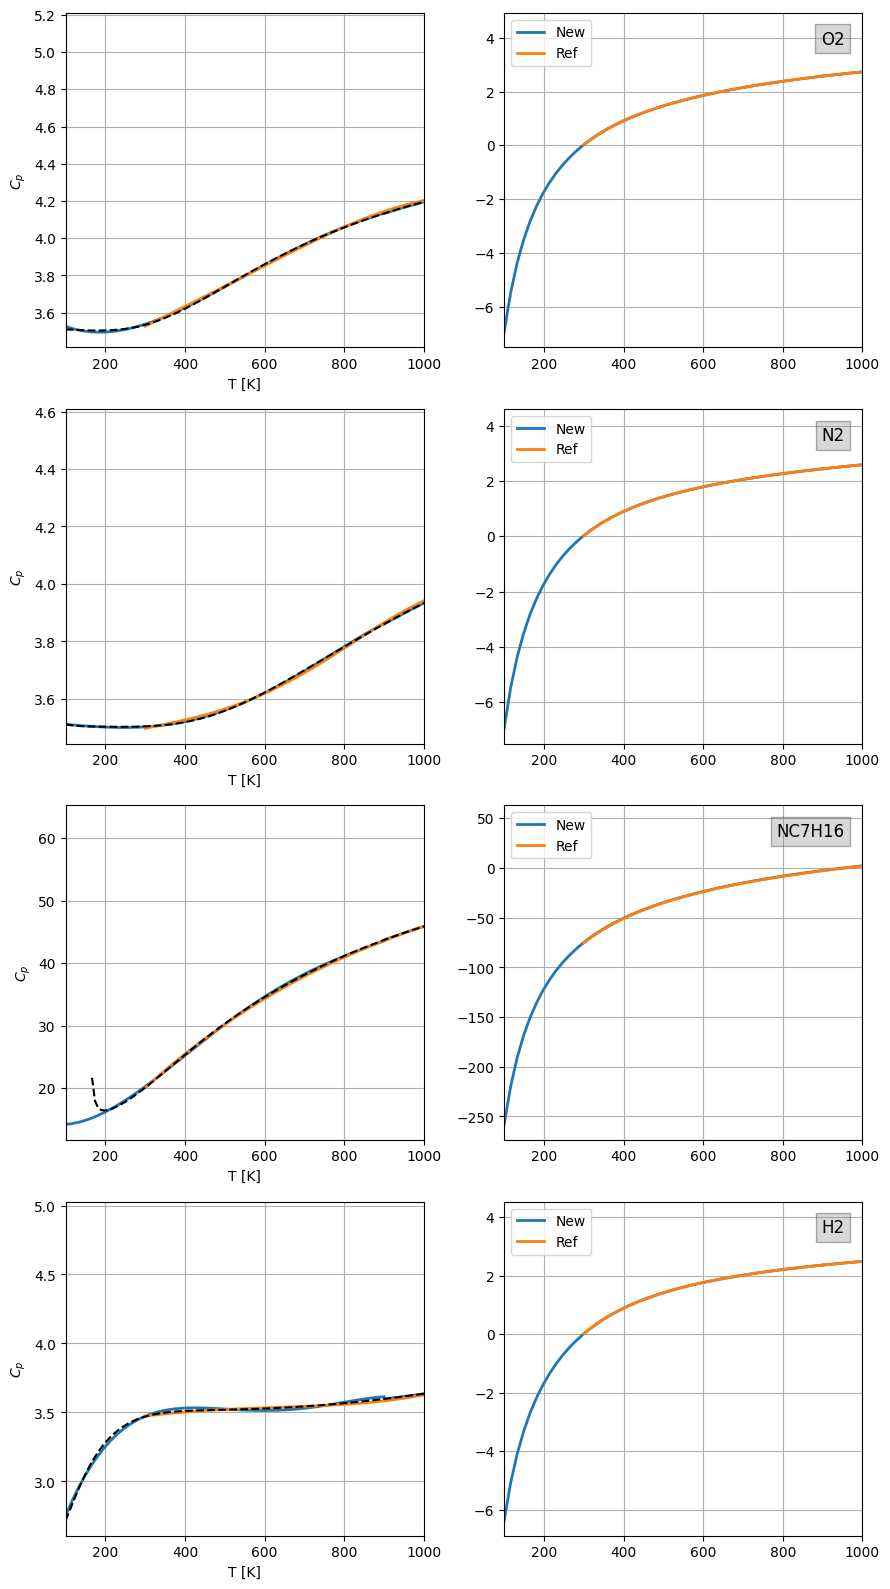

In [5]:
from generateJANAFPolynomials.genCHEMKINThermo import GenCHEMKINThermo
import matplotlib.pylab as plt

import CoolProp.CoolProp as CP
import numpy as np

TMin = 100
TMax = 1200
TCommon = 900

p = 0.1E+5

thermoFile_ref = GenCHEMKINThermo(TMin,TCommon,TMax,p)
thermoFile_ref.readChemkinFile('test/nc7_2c_therm.txt')

thermoFile = GenCHEMKINThermo(TMin,TCommon,TMax,p)
thermoFile.genThermoData(['O2','N2','NC7H16','H2'])
thermoFile.writeThermoFile("therm.dat")

# Count all species generated by the thermo library
species = []
for specie in thermoFile.species:
    if thermoFile.dataFromThermoLib(specie):
        species.append(specie)


fig, axs = plt.subplots(len(species),2,figsize=(9, len(species)*4))
axCol0 = axs[:,0]
axCol1 = axs[:,1]
T = np.linspace(TMin,TMax,150)
for specie,ax0,ax1 in zip(species,axCol0,axCol1):
    thermoFile.plot(ax0,specie,"Cp",label="New",lw=2)
    thermoFile_ref.plot(ax0,specie,"Cp",label="Ref",lw=2)
    RGas = (8.314/CP.PropsSI('M',specie))
    ax0.plot(T,CP.PropsSI('C','T|gas',T,'P',p,specie)/RGas,ls='--',color='k')
    ax0.set_xlabel('T [K]')
    ax0.set_ylabel(r'$C_p$ ')
    ax0.grid()
    ax0.set_xlim([TMin,1000])

    thermoFile.plot(ax1,specie,"H",label="New",lw=2)
    thermoFile_ref.plot(ax1,specie,"H",label="Ref",lw=2)
    ax1.grid()
    ax1.set_xlim([TMin,1000])
    ax1.legend()
    ax1.annotate(specie, xy=(0.95, 0.95), xycoords='axes fraction', 
                horizontalalignment='right', verticalalignment='top',fontsize=12,
                bbox=dict(facecolor='gray', edgecolor='k',alpha=0.3))
plt.tight_layout()

In [ ]:
# def get_specie_alias_name(specie_long_name):
#     """Get the species alias names from CoolProp
#     """

#     # Try to find the name in one of the aliases
#     for fluid in CP.FluidsList():
#         alias_upper_case = [word.upper() for word in CP.get_aliases(fluid)]
#         for alias in alias_upper_case:
#             if alias == specie_long_name:
#                 return alias_upper_case
#     return [specie_long_name]


# # Generate a new file
# with open("heatOfFormation.dat","w") as out_file:
#     with open("generateJANAFPolynomials/heatOfFormation.dat","r") as in_file:
#          for line in in_file:
#                 lineParts = line.split(';')
#                 # Add all the alias names to the long name
#                 alias_names = get_specie_alias_name(lineParts[1].upper())

#                 line_to_print = [lineParts[0]," ".join(alias_names),lineParts[2],lineParts[3]]
#                 out_file.write(";".join(line_to_print))


: 